In [1]:
include("src/WaveSolverCUDA.jl")
using .WaveSolverCUDA

In [2]:
using JLD2, ImageFiltering
import PyPlot as plt


: 

In [ ]:
@load "data/marmousi/marmousi20.jld2"
c = 1000 .* c
rho = 1000 .* rho
c0 = imfilter(c, Kernel.gaussian(10));
c0[1:23,:] .= 1500.

Nx, Ny = size(c)
dx, dy = 20, 20
Nt = 8000
Fs = 500
dt = 1/Fs
t = range(0, (Nt-1)*dt, Nt)
pml_len = 100
pml_coef = 200

a = 1 ./ rho
b = rho .* c .^ 2;

source_num = 15
source_position = zeros(2,source_num)
for i = 1:source_num
    source_position[1,i] = 5
    source_position[2,i] = 51 + (i-1)*51
end
source_vals = zeros(Nt, source_num)
for i = 1:source_num
    source_vals[:,i] = source_ricker_int(5,0.2,t) * 1e6
end

receiver_num = 425 * 2
receiver_position = zeros(2, receiver_num)
for i = 1:receiver_num
    receiver_position[1,i] = 1
    receiver_position[2,i] = (i-1)*1 + 1
end

In [3]:
println("    Computing data...")
CUDA.@time data_true, U_true = forward_acoustic_c(c, Nx, Ny, Nt, dx, dy, dt, source_num, source_position, source_vals, receiver_num, receiver_position, pml_len, pml_coef; blockx=16, blocky=16, idx_source=4, recordWaveField=true, saveRatio=1)
println("    Done.")

    Computing data...
 14.745071 seconds (24.89 M CPU allocations: 5.673 GiB, 1.18% gc time) (19 GPU allocations: 4.476 GiB, 0.04% memmgmt time)
    Done.


In [5]:
println("    Computing forward modeling...")
CUDA.@time data_forward, U_forward = forward_acoustic_c(c0, Nx, Ny, Nt, dx, dy, dt, source_num, source_position, source_vals, receiver_num, receiver_position, pml_len, pml_coef; blockx=16, blocky=16, idx_source=4, recordWaveField=true, saveRatio=1)
println("    Done.")

    Computing forward modeling...
  3.008646 seconds (1.31 M CPU allocations: 4.538 GiB, 0.98% gc time) (19 GPU allocations: 4.476 GiB, 0.10% memmgmt time)
    Done.


In [6]:
println("    Computing backward...")
# CUDA.@time data_backward, U_backward = forward_acoustic_c(c0, Nx, Ny, Nt, dx, dy, dt, receiver_num, receiver_position, adjoint_source, source_num, source_position, source_vals, pml_len, pml_coef; blockx=16, blocky=16, idx_source=0, recordWaveField=true, saveRatio=1)

rho0 = 1000 .* ones(size(c))
a = -1 ./ rho0
b = -1 .* rho0 .* c0.^2
adjoint_source = data_true - data_forward

CUDA.@time U_backward = acoustic_solver_pml(a, b, Nx, Ny, Nt, dx, dy, dt, receiver_num, receiver_position, adjoint_source, pml_len, pml_coef; blockx=16, blocky=16, order=4, recordWaveField=true)


println("    Done.")

    Computing backward...
  4.674360 seconds (4.15 M CPU allocations: 4.651 GiB, 8.93% gc time) (16 GPU allocations: 4.476 GiB, 27.21% memmgmt time)
    Done.


In [10]:
@save "data/forward_backward.jld2" U_forward U_backward data_true U_true

In [8]:
U_backward

175×850×8000 Array{Float32, 3}:
[:, :, 1] =
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0 

In [12]:
import PyPlot as plt

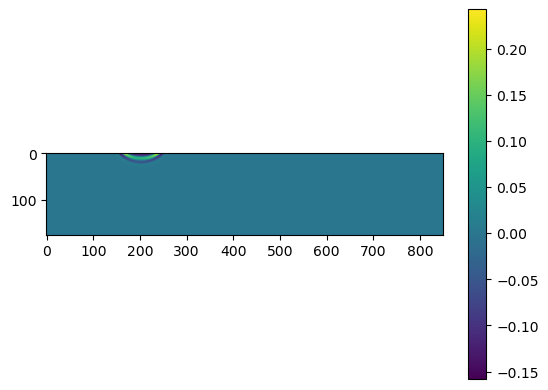

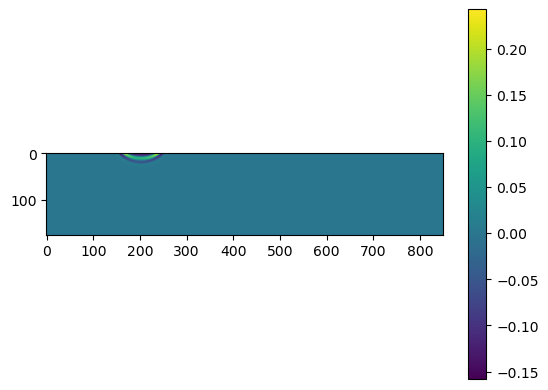

In [21]:
plt.close()
plt.figure()
plt.imshow(U_backward[:,:,500])
plt.colorbar()
plt.gcf()